# Setting up imports

In [1]:
%pip install -q pytorch-fid gradio

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Number of GPUs:', torch.cuda.device_count())

Using device: cuda
Number of GPUs: 2


In [4]:

POKEMON_DIR='/kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images/pokemondb.net'
ANIME_DIR= '/kaggle/input/datasets/soumikrakshit/anime-faces/data'
SAVE_PATH='/kaggle/working'

os.makedirs(f'{SAVE_PATH}/dcgan',        exist_ok=True)
os.makedirs(f'{SAVE_PATH}/wgangp',       exist_ok=True)
os.makedirs(f'{SAVE_PATH}/checkpoints',  exist_ok=True)

IMAGE_SIZE=64
CHANNELS=3
NOISE_SIZE=100
BATCH_SIZE=32
EPOCHS=20
LR=0.0002
CRITIC_STEPS=5
GP_WEIGHT=10

MAX_IMAGES=30000
NUM_WORKERS=0
PIN_MEMORY=False
CHECKPOINT_EVERY=2

USE_AMP = torch.cuda.is_available()
print('config okay')
print('Mixed Precision:', USE_AMP)
    

config okay
Mixed Precision: True


# Dataset Prep

In [5]:
class ImageFolder(Dataset):

    def __init__(self, folder, transform, max_images=None):
        self.transform = transform
        self.image_paths = []

        for path in Path(folder).rglob('*'):
            if path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
                self.image_paths.append(path)

        if max_images is not None:
            self.image_paths = self.image_paths[:max_images]

        print(f'Loaded {len(self.image_paths)} images from {folder}')

    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, i):
        with Image.open(self.image_paths[i]) as img:
            if img.mode == 'P' and 'transparency' in img.info:
                img = img.convert('RGBA')
            img = img.convert('RGB')
            tensor_img = self.transform(img)
        return tensor_img


img_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])

])
pokemon_data = ImageFolder(
    POKEMON_DIR,
    img_transform,
    max_images=20000 
)

pokemon_loader = DataLoader(
    pokemon_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True
)

print(f'Pokemon batches: {len(pokemon_loader)}')

Loaded 20000 images from /kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images/pokemondb.net
Pokemon batches: 625


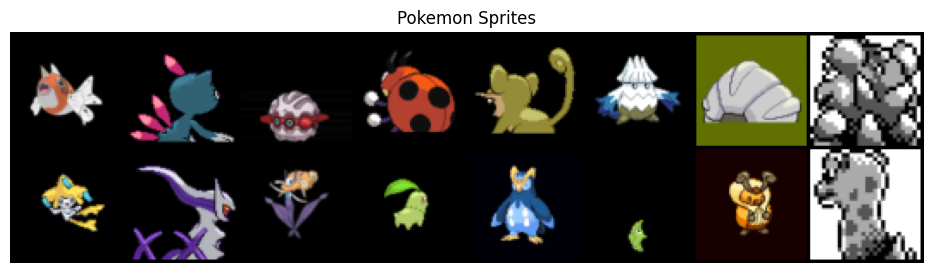

In [6]:
def show_sample(loader, title):
    batch = next(iter(loader))
    batch = batch * 0.5 + 0.5

    grid = vutils.make_grid(batch[:16], nrow=8)
    fig = plt.figure(figsize=(12,3))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')

    plt.show()
    plt.close(fig)


show_sample(pokemon_loader, 'Pokemon Sprites')

# DCGAN Generator

In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            #1*1 to 4*4
            nn.ConvTranspose2d(NOISE_SIZE,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            #4*4 to 8*8
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            
            #8*8 to 16*16
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            #4*4 to 8*8
            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64,CHANNELS,4,2,1,bias=False),
            nn.Tanh()
        )


    def forward(self,noise):
        return self.net(noise)


quick_test=Generator()
noise_test=torch.randn(4,NOISE_SIZE,1,1)
print('Generator output shape: ',quick_test(noise_test).shape)


Generator output shape:  torch.Size([4, 3, 64, 64])


In [8]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(CHANNELS, 64,  4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),
            # 32x32 -> 16x16
            nn.Conv2d(64,  128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            # 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            # 4x4 -> 1x1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
             
        )

    def forward(self, img):
        return self.net(img).view(-1)


D_test   = Discriminator()
img_test = torch.randn(4, 3, 64, 64)
print('Discriminator output shape:', D_test(img_test).shape)
del D_test, img_test

Discriminator output shape: torch.Size([4])


In [9]:
def init_weights(layer):
    name=type(layer).__name__
    if 'Conv' in name:
        nn.init.normal_(layer.weight,0.0,0.02)
    elif 'BatchNorm'in name:
        nn.init.normal_(layer.weight,1.0,0.02)
        nn.init.constant_(layer.bias,0)

print("Weight init function done")


Weight init function done


In [10]:
import gc
from tqdm import tqdm

def train_dcgan(loader, epochs=EPOCHS,resume=True):
    G = Generator().to(device)
    D = Discriminator().to(device)
    G.apply(init_weights)
    D.apply(init_weights)

    if torch.cuda.device_count() > 1:
        G = nn.DataParallel(G)
        D = nn.DataParallel(D)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

    loss_fn = nn.BCEWithLogitsLoss()

    scaler_G = GradScaler('cuda', enabled=USE_AMP)
    scaler_D = GradScaler('cuda', enabled=USE_AMP)

    fixed_noise = torch.randn(64, NOISE_SIZE, 1, 1, device=device)

    g_losses = []
    d_losses = []

    for epoch in range(1, epochs +1 ):
        G.train()
        D.train()
        g_total = 0
        d_total = 0

        pbar = tqdm(loader, desc=f'DCGAN Epoch {epoch}/{epochs}', leave=False)

        for real_imgs in pbar:
            real_imgs   = real_imgs.to(device)
            b           = real_imgs.size(0)
            real_labels = torch.ones(b,  device=device)
            fake_labels = torch.zeros(b, device=device)

            opt_D.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_AMP):
                d_real    = loss_fn(D(real_imgs), real_labels)
                noise     = torch.randn(b, NOISE_SIZE, 1, 1, device=device)
                fake_imgs = G(noise).detach()
                d_fake    = loss_fn(D(fake_imgs), fake_labels)
                d_loss    = d_real + d_fake
            scaler_D.scale(d_loss).backward()
            scaler_D.step(opt_D)
            scaler_D.update()
            d_batch=d_loss.item()
            del fake_imgs, noise, d_real, d_fake, d_loss

            opt_G.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_AMP):
                noise     = torch.randn(b, NOISE_SIZE, 1, 1, device=device)
                fake_imgs = G(noise)
                g_loss    = loss_fn(D(fake_imgs), real_labels)
            scaler_G.scale(g_loss).backward()
            scaler_G.step(opt_G)
            scaler_G.update()
            g_batch=g_loss.item()
            del fake_imgs,noise,g_loss

            g_total += g_batch
            d_total += d_batch
            pbar.set_postfix(G=f'{g_batch:.3f}', D=f'{d_batch:.3f}')

        pbar.close()
        g_losses.append(g_total / len(loader))
        d_losses.append(d_total / len(loader))
        print(f'Epoch {epoch}/{epochs}  G_loss: {g_losses[-1]:.4f}  D_loss: {d_losses[-1]:.4f}')
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if epoch % CHECKPOINT_EVERY == 0 or epoch == epochs:
            G_save = G.module if hasattr(G, 'module') else G
            torch.save(G_save.state_dict(), f'{SAVE_PATH}/dcgan_gen_latest.pt')

        if epoch % 10 == 0 or epoch == epochs:
            G.eval()
            with torch.no_grad():
                fake = G(fixed_noise).cpu() * 0.5 + 0.5
            vutils.save_image(fake, f'{SAVE_PATH}/dcgan/epoch_{epoch}.png', nrow=8)
            del fake
            G.train()

    G_model = G.module if hasattr(G, 'module') else G
    torch.save(G_model.state_dict(), f'{SAVE_PATH}/dcgan_generator_final.pt')
    torch.save({'g': g_losses, 'd': d_losses}, f'{SAVE_PATH}/dcgan_losses.pt')
    print(f"DCGAN model and losses successfully exported to {SAVE_PATH}/")
    return G_model, g_losses, d_losses


dcgan_G, dcgan_g_losses, dcgan_d_losses = train_dcgan(pokemon_loader)
dcgan_G = dcgan_G.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Moved DCGAN generator to CPU to free GPU memory for WGAN-GP.')

Epoch 1/20  G_loss: 7.0718  D_loss: 0.4514


Epoch 2/20  G_loss: 3.3902  D_loss: 0.6234


Epoch 3/20  G_loss: 3.3046  D_loss: 0.5917


Epoch 4/20  G_loss: 3.1663  D_loss: 0.6478


Epoch 5/20  G_loss: 3.0746  D_loss: 0.6523


...

Epoch 16/20  G_loss: 3.8392  D_loss: 0.4099


Epoch 17/20  G_loss: 4.0032  D_loss: 0.3633


Epoch 18/20  G_loss: 4.0022  D_loss: 0.3868


Epoch 19/20  G_loss: 4.1872  D_loss: 0.3802


Epoch 20/20  G_loss: 4.1129  D_loss: 0.3609
DCGAN model and losses successfully exported to /kaggle/working/
Moved DCGAN generator to CPU to free GPU memory for WGAN-GP.


# Working on WGACN-GP
Here discriminator is replaced with Critic

In [11]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(CHANNELS,64,4,2,1,bias=False),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(64,128,4,2,1,bias=False),
            nn.InstanceNorm2d(128,affine=True),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(128,256,4,2,1,bias=False),
            nn.InstanceNorm2d(256,affine=True),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(256,512,4,2,1,bias=False),
            nn.InstanceNorm2d(512,affine=True),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(512,1,4,1,0,bias=False),
            
        )

    def forward(self,img):
        return self.net(img).view(-1)

In [12]:
def gradient_penalty(critic, real, fake):
    b = real.size(0)
    alpha = torch.rand(b, 1, 1, 1, device=device)
    mixed = (alpha * real + (1 - alpha) * fake).detach().requires_grad_(True)
    score = critic(mixed)
    grad = torch.autograd.grad(
        outputs=score.sum(),  
        inputs=mixed,
        create_graph=True
    )[0]
    gp = ((grad.view(b, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp  

In [13]:
import gc
import os

def train_wgangp(loader, epochs=10, resume=True, gp_batch_size=8):
    USE_AMP_W = torch.cuda.is_available()

    G = Generator().to(device)
    C = Critic().to(device)
    G.apply(init_weights)
    C.apply(init_weights)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_C = torch.optim.Adam(C.parameters(), lr=LR, betas=(0.5, 0.999))

    scaler_G = GradScaler('cuda', enabled=USE_AMP_W)
    scaler_C = GradScaler('cuda', enabled=USE_AMP_W)

    g_losses = []
    c_losses = []
    start_epoch = 1

    if resume and os.path.exists(f'{SAVE_PATH}/wgangp_checkpoint.pt'):
        ckpt = torch.load(f'{SAVE_PATH}/wgangp_checkpoint.pt', map_location=device)
        G.load_state_dict(ckpt['G'])
        C.load_state_dict(ckpt['C'])
        opt_G.load_state_dict(ckpt['opt_G'])
        opt_C.load_state_dict(ckpt['opt_C'])
        start_epoch = ckpt['epoch'] + 1
        g_losses = ckpt['g_losses']
        c_losses = ckpt['c_losses']
        print(f'Resumed from epoch {ckpt["epoch"]}')

    for epoch in range(start_epoch, epochs + 1):
        G.train()
        C.train()
        g_total = 0.0
        c_total = 0.0
        valid_steps = 0

        pbar = tqdm(loader, desc=f'WGAN-GP Epoch {epoch}/{epochs}', leave=False)

        for real_imgs in pbar:
            try:
                real_imgs = real_imgs.to(device, non_blocking=False)
                b = real_imgs.size(0)

                for _ in range(CRITIC_STEPS):
                    opt_C.zero_grad(set_to_none=True)

                    with torch.no_grad():
                        noise = torch.randn(b, NOISE_SIZE, 1, 1, device=device)
                        fake_imgs = G(noise)

                    with autocast('cuda', enabled=USE_AMP_W):
                        c_real = C(real_imgs)
                        c_fake = C(fake_imgs.detach())
                        wasserstein = c_fake.mean() - c_real.mean()

                    gp_n = min(gp_batch_size, b)
                    gp = gradient_penalty(C, real_imgs[:gp_n].float(), fake_imgs[:gp_n].float())
                    c_loss = wasserstein + GP_WEIGHT * gp

                    scaler_C.scale(c_loss).backward()
                    scaler_C.step(opt_C)
                    scaler_C.update()

                    c_loss_val = c_loss.item()
                    del noise, fake_imgs, c_real, c_fake, wasserstein, gp, c_loss

                opt_G.zero_grad(set_to_none=True)
                with autocast('cuda', enabled=USE_AMP_W):
                    noise = torch.randn(b, NOISE_SIZE, 1, 1, device=device)
                    fake_imgs = G(noise)
                    g_loss = -C(fake_imgs).mean()

                scaler_G.scale(g_loss).backward()
                scaler_G.step(opt_G)
                scaler_G.update()

                g_loss_val = g_loss.item()
                g_total += g_loss_val
                c_total += c_loss_val
                valid_steps += 1

                pbar.set_postfix(G=f'{g_loss_val:.3f}', C=f'{c_loss_val:.3f}')
                del noise, fake_imgs, g_loss, real_imgs

            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    print('OOM batch skipped to keep training alive.')
                    opt_C.zero_grad(set_to_none=True)
                    opt_G.zero_grad(set_to_none=True)
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    gc.collect()
                    continue
                raise

        pbar.close()
        steps = max(valid_steps, 1)
        g_losses.append(g_total / steps)
        c_losses.append(c_total / steps)
        print(f'Epoch {epoch}/{epochs}  G_loss: {g_losses[-1]:.4f}  C_loss: {c_losses[-1]:.4f}')

        if epoch % CHECKPOINT_EVERY == 0 or epoch == epochs:
            torch.save({
                'epoch': epoch,
                'G': G.state_dict(),
                'C': C.state_dict(),
                'opt_G': opt_G.state_dict(),
                'opt_C': opt_C.state_dict(),
                'g_losses': g_losses,
                'c_losses': c_losses,
            }, f'{SAVE_PATH}/wgangp_checkpoint.pt')

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    torch.save(G.state_dict(), f'{SAVE_PATH}/wgangp_generator_final.pt')
    torch.save({'g': g_losses, 'c': c_losses}, f'{SAVE_PATH}/wgangp_losses.pt')
    print(f"WGAN-GP model and losses successfully exported to {SAVE_PATH}/")
    return G, g_losses, c_losses


ckpt = f'{SAVE_PATH}/wgangp_checkpoint.pt'
if os.path.exists(ckpt):
    os.remove(ckpt)
    print('checkpoint deleted')

wgangp_G, wgangp_g_losses, wgangp_c_losses = train_wgangp(pokemon_loader, resume=False)
wgangp_G = wgangp_G.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Epoch 1/10  G_loss: 21.2613  C_loss: -17.3782


Epoch 2/10  G_loss: 22.0081  C_loss: -20.7715


Epoch 3/10  G_loss: 21.2039  C_loss: -18.3187


Epoch 4/10  G_loss: 23.7007  C_loss: -17.2621


Epoch 5/10  G_loss: 24.9569  C_loss: -16.7050


Epoch 6/10  G_loss: 22.6150  C_loss: -16.7929


Epoch 7/10  G_loss: 27.4273  C_loss: -16.9581


Epoch 8/10  G_loss: 30.0981  C_loss: -16.5069


Epoch 9/10  G_loss: 31.5255  C_loss: -15.8057


Epoch 10/10  G_loss: 33.9151  C_loss: -15.7706
WGAN-GP model and losses successfully exported to /kaggle/working/


In [ ]:
# import gc
# import psutil

# # free everything possible
# for name in ['wgangp_G', 'dcgan_G', 'anime_loader', 'pokemon_loader', 
#              'anime_data', 'pokemon_data']:
#     if name in dir():
#         del globals()[name]

# gc.collect()
# torch.cuda.empty_cache()

# ram = psutil.virtual_memory()
# print(f'RAM: {ram.used/1024**3:.1f} GB / {ram.total/1024**3:.1f} GB')
# print(f'GPU allocated: {torch.cuda.memory_allocated()/1024**3:.1f} GB')
# print(f'GPU reserved:  {torch.cuda.memory_reserved()/1024**3:.1f} GB')

# Plotting

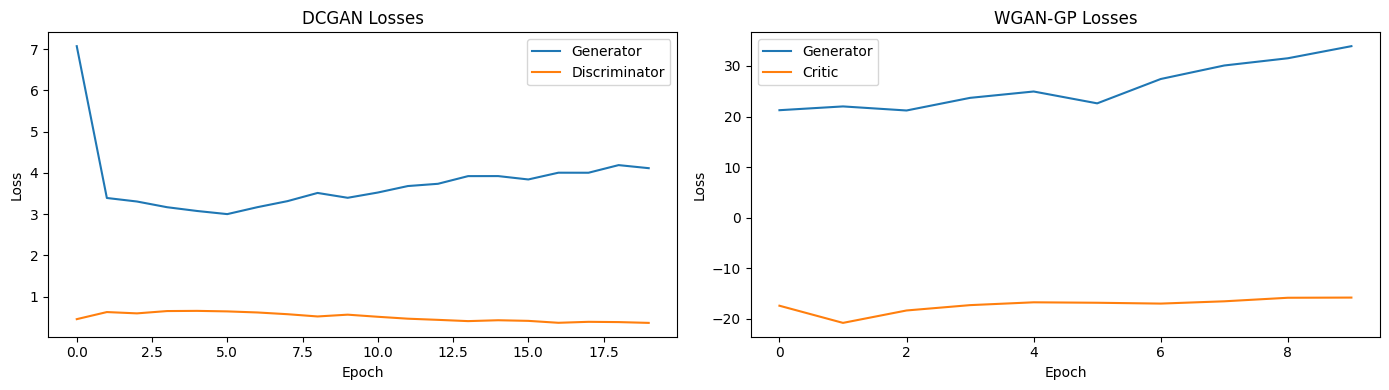

In [14]:
import os

dcgan_losses_loaded = torch.load(f'{SAVE_PATH}/dcgan_losses.pt', map_location='cpu')
wgangp_losses_loaded = torch.load(f'{SAVE_PATH}/wgangp_losses.pt', map_location='cpu')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dcgan_losses_loaded['g'], label='Generator')
axes[0].plot(dcgan_losses_loaded['d'], label='Discriminator')
axes[0].set_title('DCGAN Losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(wgangp_losses_loaded['g'], label='Generator')
axes[1].plot(wgangp_losses_loaded['c'], label='Critic')
axes[1].set_title('WGAN-GP Losses')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/loss_curves.png', dpi=120)
plt.show()

plt.close(fig)

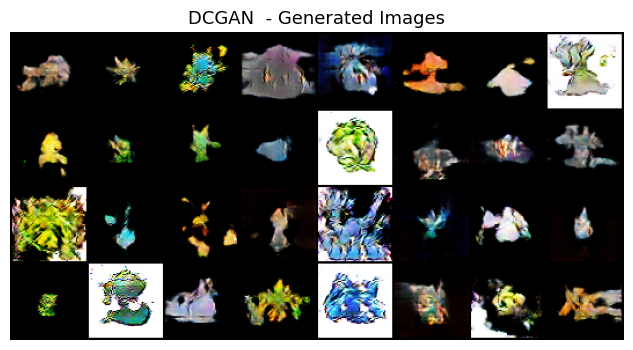

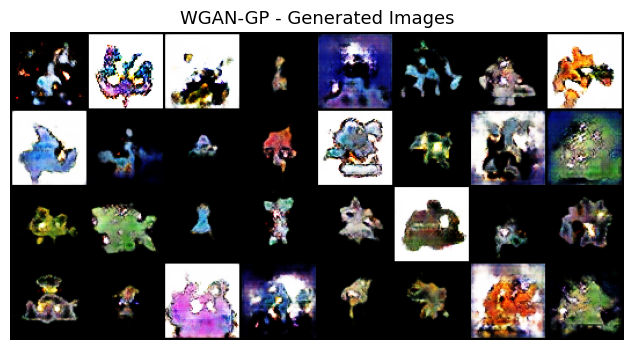

In [15]:
def show_generated(G, title, n=32):
    model_device = next(G.parameters()).device
    G.eval()
    with torch.no_grad():
        noise = torch.randn(n, NOISE_SIZE, 1, 1, device=model_device)
        imgs  = G(noise).detach().cpu() * 0.5 + 0.5
    grid = vutils.make_grid(imgs, nrow=8)
    plt.figure(figsize=(14, 4))
    plt.title(title, fontsize=13)
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.axis('off')
    plt.show()

show_generated(dcgan_G,  'DCGAN  - Generated Images')
show_generated(wgangp_G, 'WGAN-GP - Generated Images')

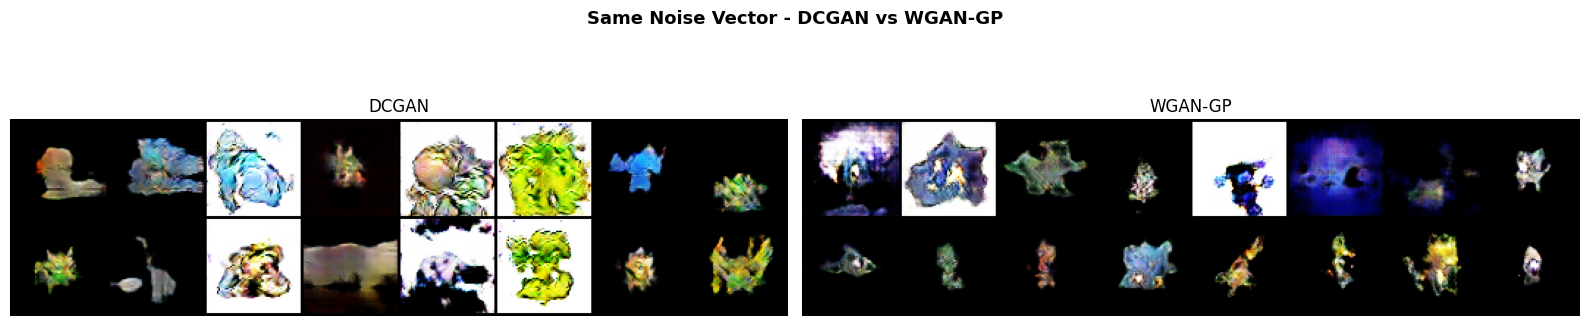

In [16]:
def show_comparison(G1, G2):
    d1 = next(G1.parameters()).device
    d2 = next(G2.parameters()).device
    noise_cpu = torch.randn(16, NOISE_SIZE, 1, 1)
    G1.eval()
    G2.eval()
    with torch.no_grad():
        imgs1 = (G1(noise_cpu.to(d1)).detach().cpu() * 0.5 + 0.5).clamp(0, 1)
        imgs2 = (G2(noise_cpu.to(d2)).detach().cpu() * 0.5 + 0.5).clamp(0, 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Same Noise Vector - DCGAN vs WGAN-GP', fontsize=13, fontweight='bold')
    ax1.imshow(vutils.make_grid(imgs1, nrow=8).permute(1, 2, 0))
    ax1.set_title('DCGAN')
    ax1.axis('off')
    ax2.imshow(vutils.make_grid(imgs2, nrow=8).permute(1, 2, 0))
    ax2.set_title('WGAN-GP')
    ax2.axis('off')
    plt.tight_layout()
    plt.savefig(f'{SAVE_PATH}/comparison.png', dpi=120)
    plt.show()

show_comparison(dcgan_G, wgangp_G)

In [17]:
def diversity_score(G, n=500):
    model_device = next(G.parameters()).device
    G.eval()
    all_imgs = []
    with torch.no_grad():
        for _ in range(0, n, 64):
            noise = torch.randn(64, NOISE_SIZE, 1, 1, device=model_device)
            all_imgs.append(G(noise).detach().cpu())
    all_imgs = torch.cat(all_imgs)[:n]
    return all_imgs.std(dim=0).mean().item()

dcgan_div  = diversity_score(dcgan_G)
wgangp_div = diversity_score(wgangp_G)

print(f'Diversity Score (higher = better)')
print(f'  DCGAN   : {dcgan_div:.4f}')
print(f'  WGAN-GP : {wgangp_div:.4f}')

Diversity Score (higher = better)
  DCGAN   : 0.7918
  WGAN-GP : 0.7888


# Gradio

In [18]:
import gradio as gr
import numpy as np

app_dcgan  = Generator().to(device)
app_wgangp = Generator().to(device)
app_dcgan.load_state_dict(torch.load(f'{SAVE_PATH}/dcgan_generator_final.pt',  map_location=device))
app_wgangp.load_state_dict(torch.load(f'{SAVE_PATH}/wgangp_generator_final.pt', map_location=device))
app_dcgan.eval()
app_wgangp.eval()


def to_np(t):
    return (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def generate(model_name, num_images, seed):
    if int(seed) >= 0:
        torch.manual_seed(int(seed))
    G     = app_dcgan if model_name == 'DCGAN' else app_wgangp
    noise = torch.randn(int(num_images), NOISE_SIZE, 1, 1, device=device)
    with torch.no_grad():
        imgs = (G(noise).cpu() * 0.5 + 0.5).clamp(0, 1)
    return [to_np(img) for img in imgs]


def compare(num_images, seed):
    if int(seed) >= 0:
        torch.manual_seed(int(seed))
    noise = torch.randn(int(num_images), NOISE_SIZE, 1, 1, device=device)
    with torch.no_grad():
        d_imgs = (app_dcgan(noise).cpu()  * 0.5 + 0.5).clamp(0, 1)
        w_imgs = (app_wgangp(noise).cpu() * 0.5 + 0.5).clamp(0, 1)
    return [to_np(img) for img in list(d_imgs) + list(w_imgs)]


with gr.Blocks(title='GAN Demo') as app:
    gr.Markdown('# GAN Demo — DCGAN vs WGAN-GP')

    with gr.Tabs():
        with gr.TabItem('Generate'):
            with gr.Row():
                model_dd = gr.Dropdown(['DCGAN', 'WGAN-GP'], value='WGAN-GP', label='Model')
                n_slider = gr.Slider(1, 64, value=16, step=1, label='Number of images')
                seed_box = gr.Number(value=-1, label='Seed (-1 = random)')
                gen_btn  = gr.Button('Generate', variant='primary')
            gallery = gr.Gallery(label='Generated Images', columns=8)
            gen_btn.click(generate, inputs=[model_dd, n_slider, seed_box], outputs=gallery)

        with gr.TabItem('Compare (same noise)'):
            gr.Markdown('First N = DCGAN | Last N = WGAN-GP — identical noise vector')
            with gr.Row():
                cmp_n   = gr.Slider(1, 16, value=8, step=1, label='Images per model')
                cmp_seed = gr.Number(value=42, label='Seed')
                cmp_btn = gr.Button('Compare', variant='primary')
            cmp_gallery = gr.Gallery(columns=8)
            cmp_btn.click(compare, inputs=[cmp_n, cmp_seed], outputs=cmp_gallery)

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0dfe0003612ed86aba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
